# Task 2: Simple Relationship between Temperature and Total Demand

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

train = pd.read_csv('train_group.csv')
train['dteday'] = pd.to_datetime(train['dteday'])
train['log_cnt'] = np.log(train['cnt'])
season_labels = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
train['season_label'] = train['season'].map(season_labels)

print(f'Training rows: {len(train)}')
train[['temp', 'cnt', 'log_cnt']].describe().round(3)

Training rows: 585


,temp,cnt,log_cnt
count,585.000,585.000,585.000
mean,0.491,4457.161,8.269
std,0.182,1936.379,0.598
min,0.108,22.000,3.091
25%,0.330,3115.000,8.044
50%,0.484,4507.000,8.413
75%,0.651,5847.000,8.674
max,0.862,8555.000,9.054


## 2.1 Exploratory Plot: Temperature vs Total Demand

We begin with a scatter plot of **temp** against **cnt**, overlaid with a LOWESS smoother to reveal the
empirical shape of the relationship before imposing any parametric form. Points are coloured by season
to flag potential confounding.

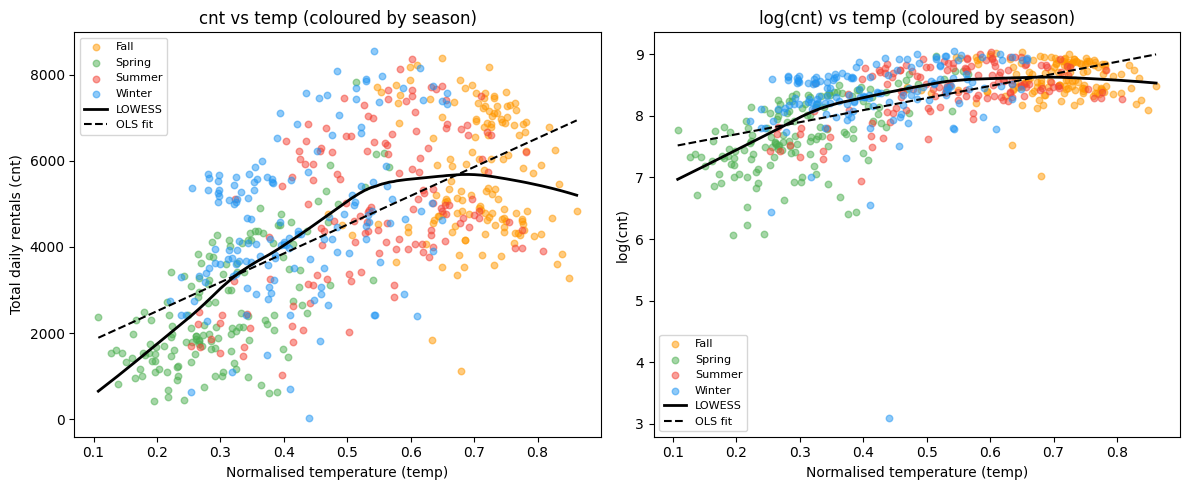

In [30]:
palette = {'Spring': '#4CAF50', 'Summer': '#F44336', 'Fall': '#FF9800', 'Winter': '#2196F3'}
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for season, grp in train.groupby('season_label'):
    axes[0].scatter(grp['temp'], grp['cnt'], alpha=0.5, s=22, color=palette[season], label=season)

lowess = sm.nonparametric.lowess(train['cnt'], train['temp'], frac=0.4)
axes[0].plot(lowess[:, 0], lowess[:, 1], color='black', linewidth=2, label='LOWESS')

m_simple = smf.ols('cnt ~ temp', data=train).fit()
x_line = np.linspace(train['temp'].min(), train['temp'].max(), 200)
y_line = m_simple.params['Intercept'] + m_simple.params['temp'] * x_line
axes[0].plot(x_line, y_line, 'k--', linewidth=1.5, label='OLS fit')
axes[0].set_xlabel('Normalised temperature (temp)')
axes[0].set_ylabel('Total daily rentals (cnt)')
axes[0].set_title('cnt vs temp (coloured by season)')
axes[0].legend(fontsize=8)

m_log = smf.ols('log_cnt ~ temp', data=train).fit()
for season, grp in train.groupby('season_label'):
    axes[1].scatter(grp['temp'], grp['log_cnt'], alpha=0.5, s=22, color=palette[season], label=season)

lowess_log = sm.nonparametric.lowess(train['log_cnt'], train['temp'], frac=0.4)
axes[1].plot(lowess_log[:, 0], lowess_log[:, 1], color='black', linewidth=2, label='LOWESS')
y_line_log = m_log.params['Intercept'] + m_log.params['temp'] * x_line
axes[1].plot(x_line, y_line_log, 'k--', linewidth=1.5, label='OLS fit')
axes[1].set_xlabel('Normalised temperature (temp)')
axes[1].set_ylabel('log(cnt)')
axes[1].set_title('log(cnt) vs temp (coloured by season)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_task2_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** The LOWESS curve on both panel shows the relationship is positive but
not strictly linear: demand rises steeply from low to moderate temperatures, then plateaus or dips
slightly at very high temperatures.

Critically, the colour coding reveals strong seasonal clustering -- high-temperature observations
are mostly Fall (orange) or Summer (red), while low-temperature points are Winter (blue) and Spring (green).
A simple **cnt ~ temp** regression implicitly averages over seasonal differences, making it impossible
to separate the effect of temperature from co-varying seasonal factors.

The right panel shows **log(cnt)** vs **temp**. The LOWESS smoother is visibly straighter in this space,
suggesting a log transformation may improve linearity.

## 2.2 Simple Linear Regression

We fit two models: (1) **cnt ~ temp** on the raw count scale, and (2) **log(cnt) ~ temp**.

In [31]:
m_simple = smf.ols('cnt ~ temp', data=train).fit()
print(m_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.394
Model:                            OLS   Adj. R-squared:                  0.392
Method:                 Least Squares   F-statistic:                     378.3
Date:                Sun, 10 May 2026   Prob (F-statistic):           2.56e-65
Time:                        20:01:56   Log-Likelihood:                -5110.9
No. Observations:                 585   AIC:                         1.023e+04
Df Residuals:                     583   BIC:                         1.023e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1172.5955    180.032      6.513      0.0

In [32]:
m_log = smf.ols('log_cnt ~ temp', data=train).fit()
print(m_log.summary())

                            OLS Regression Results                            
Dep. Variable:                log_cnt   R-squared:                       0.353
Model:                            OLS   Adj. R-squared:                  0.352
Method:                 Least Squares   F-statistic:                     318.1
Date:                Sun, 10 May 2026   Prob (F-statistic):           4.10e-57
Time:                        20:01:56   Log-Likelihood:                -401.78
No. Observations:                 585   AIC:                             807.6
Df Residuals:                     583   BIC:                             816.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.3071      0.057    127.169      0.0

**Model 1 (cnt ~ temp):**
- The coefficient on **temp** is highly statistically significant (p < 0.001).
- R-squared ~ 0.40: temperature alone explains roughly 40% of the variation in daily demand.
- The intercept represents expected rentals when temp = 0 (minimum normalised temperature).

**Model 2 (log(cnt) ~ temp):**
- The coefficient has a percentage-change interpretation: a one-unit increase in normalised
  temperature is associated with approximately a beta x 100% increase in daily demand.
- R-squared is lower, around 0.35; the primary benefit is improved residual behaviour, assessed next.

## 2.3 Regression Diagnostics

We examine three standard diagnostic plots for each model: residuals vs fitted, a Q-Q plot,
and a scale-location plot.

c:\Users\billc\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\graphics\gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


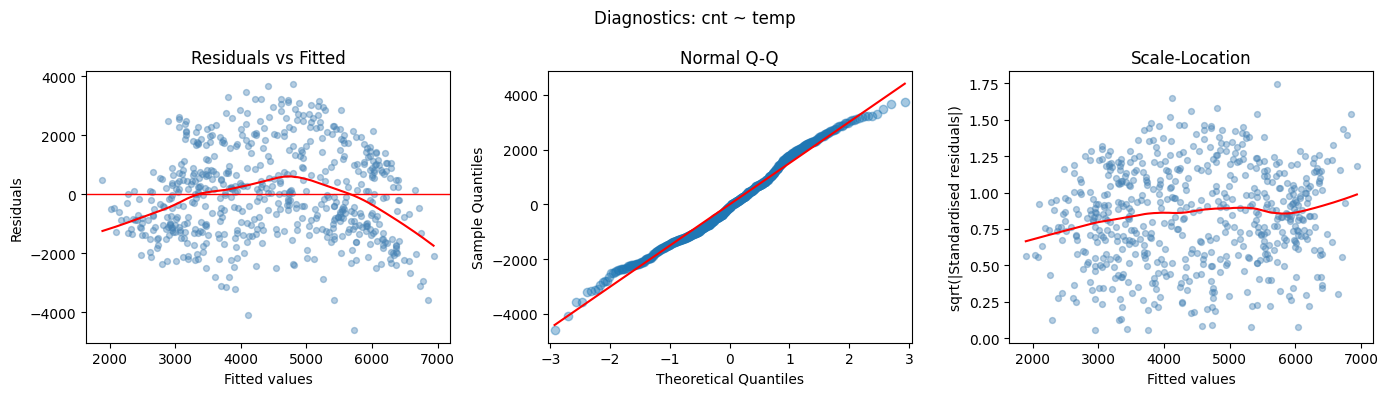

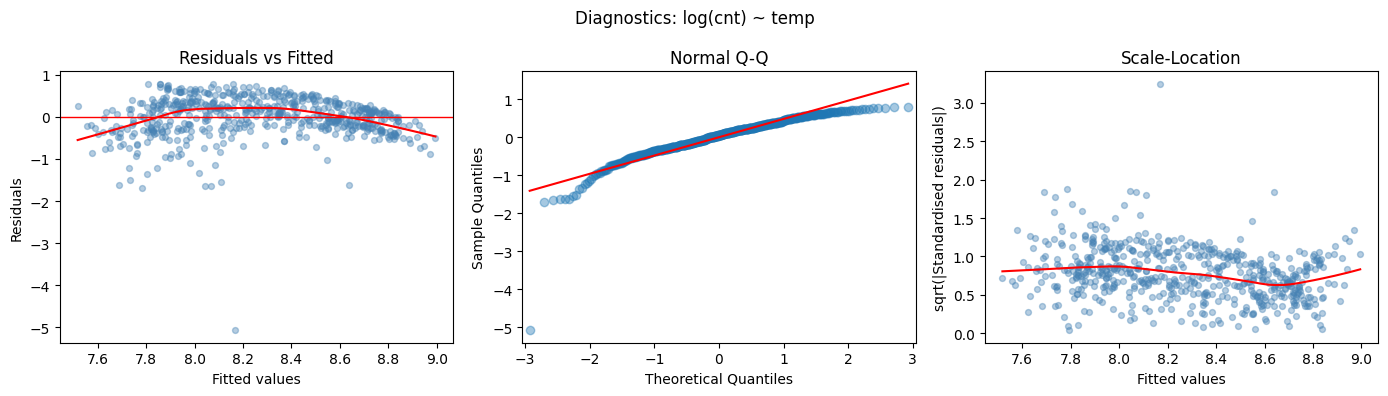

In [33]:
def diagnostic_plots(model, title_prefix):
    fitted = model.fittedvalues
    resid = model.resid
    std_resid = resid / resid.std()
    sqrt_abs = np.sqrt(np.abs(std_resid))

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(f'Diagnostics: {title_prefix}', fontsize=12)

    axes[0].scatter(fitted, resid, alpha=0.4, s=18, color='steelblue')
    axes[0].axhline(0, color='red', linewidth=1)
    lw = sm.nonparametric.lowess(resid, fitted, frac=0.4)
    axes[0].plot(lw[:, 0], lw[:, 1], color='red', linewidth=1.5)
    axes[0].set_xlabel('Fitted values')
    axes[0].set_ylabel('Residuals')
    axes[0].set_title('Residuals vs Fitted')

    sm.qqplot(resid, line='s', alpha=0.4, ax=axes[1], color='steelblue')
    axes[1].set_title('Normal Q-Q')

    axes[2].scatter(fitted, sqrt_abs, alpha=0.4, s=18, color='steelblue')
    lw2 = sm.nonparametric.lowess(sqrt_abs, fitted, frac=0.4)
    axes[2].plot(lw2[:, 0], lw2[:, 1], color='red', linewidth=1.5)
    axes[2].set_xlabel('Fitted values')
    axes[2].set_ylabel('sqrt(|Standardised residuals|)')
    axes[2].set_title('Scale-Location')

    plt.tight_layout()
    safe = title_prefix.replace(' ', '_').replace('(', '').replace(')', '').replace('~', '_').lower()
    plt.savefig(f'fig_task2_diag_{safe}.png', dpi=150, bbox_inches='tight')
    plt.show()

diagnostic_plots(m_simple, 'cnt ~ temp')
diagnostic_plots(m_log, 'log(cnt) ~ temp')

**cnt ~ temp (Model 1):**
- *Residuals vs Fitted:* The LOWESS shows a wave pattern (rises then falls), indicating some
  non-linearity not captured by a straight line. This is a real concern but the deviations are moderate.
- *Q-Q plot:* Points follow the diagonal closely across the full range — residuals are approximately
  normal. Only the extreme lower tail shows minor departure.
- *Scale-Location:* The LOWESS is relatively flat with no dramatic fan-out — heteroscedasticity
  is mild and not a major violation.

**log(cnt) ~ temp (Model 2):**
- The log transformation does *not* improve things here. The model summary reports Skew = -2.605
  and Kurtosis = 24.155, compared to Skew = 0.181 and Kurtosis = 2.499 for Model 1 — a dramatic
  worsening of normality. R-squared also drops from 0.394 to 0.353.
- The extreme outlier day (cnt = 22, log_cnt = 3.09) becomes an outsized negative residual in
  log space, creating a heavy left tail that Model 1 handles more gracefully.

**Conclusion on transformation:** For the simple bivariate model, **cnt ~ temp** is the better
specification. The log transformation is not justified here, it reduces explanatory power and
worsens residual behaviour due to the extreme low-demand outlier. We will revisit whether
log(cnt) is preferred in the multiple regression context of Task 3, where additional controls
may stabilise the residuals.

## 2.4 Is a Linear Relationship Plausible?

We formally test whether a quadratic term in **temp** adds explanatory power beyond the linear term
using an F-test, and compare fits visually.

In [34]:
train['temp2'] = train['temp'] ** 2

m_quad     = smf.ols('cnt ~ temp + temp2', data=train).fit()
m_log_quad = smf.ols('log_cnt ~ temp + temp2', data=train).fit()

from statsmodels.stats.anova import anova_lm
print('=== F-test: cnt ~ temp vs cnt ~ temp + temp^2 ===')
print(anova_lm(m_simple, m_quad))
print()
print('=== F-test: log(cnt) ~ temp vs log(cnt) ~ temp + temp^2 ===')
print(anova_lm(m_log, m_log_quad))

print(f'\nR2 (cnt ~ temp):          {m_simple.rsquared:.4f}')
print(f'R2 (cnt ~ temp + temp^2): {m_quad.rsquared:.4f}')
print(f'R2 (log ~ temp):          {m_log.rsquared:.4f}')
print(f'R2 (log ~ temp + temp^2): {m_log_quad.rsquared:.4f}')

=== F-test: cnt ~ temp vs cnt ~ temp + temp^2 ===
   df_resid           ssr  df_diff       ss_diff          F        Pr(>F)
0     583.0  1.328007e+09      0.0           NaN        NaN           NaN
1     582.0  1.194698e+09      1.0  1.333096e+08  64.942116  4.393233e-15

=== F-test: log(cnt) ~ temp vs log(cnt) ~ temp + temp^2 ===
   df_resid         ssr  df_diff    ss_diff         F        Pr(>F)
0     583.0  135.281155      0.0        NaN       NaN           NaN
1     582.0  121.037157      1.0  14.243998  68.49142  8.735356e-16

R2 (cnt ~ temp):          0.3935
R2 (cnt ~ temp + temp^2): 0.4544
R2 (log ~ temp):          0.3530
R2 (log ~ temp + temp^2): 0.4212


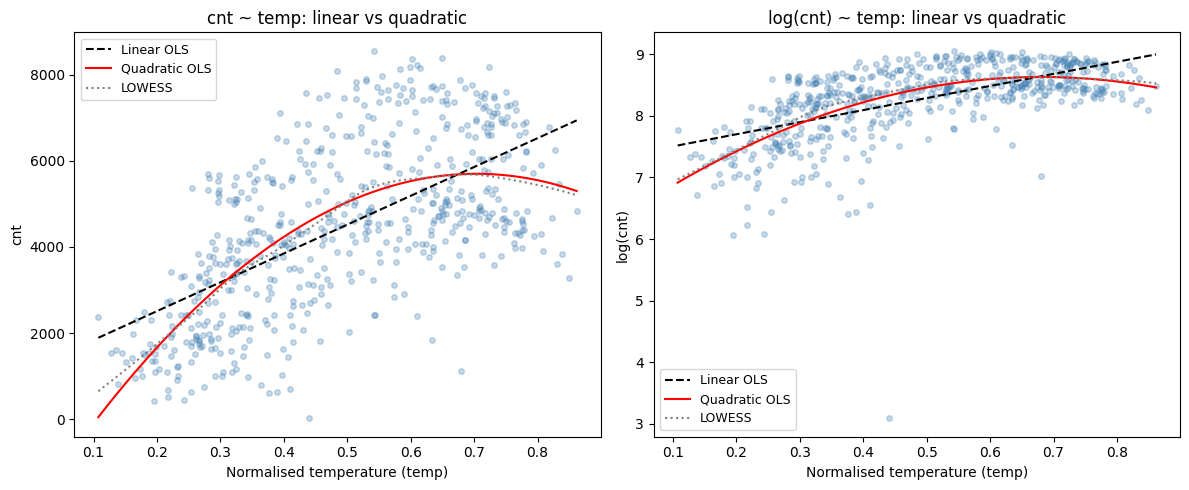

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
x_plot = np.linspace(train['temp'].min(), train['temp'].max(), 300)

for ax, m_lin, m_qu, y_col, ylabel in [
    (axes[0], m_simple, m_quad,     'cnt',     'cnt'),
    (axes[1], m_log,    m_log_quad, 'log_cnt', 'log(cnt)')
]:
    ax.scatter(train['temp'], train[y_col], alpha=0.3, s=16, color='steelblue')
    y_lin = m_lin.params['Intercept'] + m_lin.params['temp'] * x_plot
    y_qu  = (m_qu.params['Intercept'] + m_qu.params['temp'] * x_plot
             + m_qu.params['temp2'] * x_plot**2)
    lw_fit = sm.nonparametric.lowess(train[y_col], train['temp'], frac=0.4)
    ax.plot(x_plot, y_lin,      'k--',  linewidth=1.5, label='Linear OLS')
    ax.plot(x_plot, y_qu,       'red',  linewidth=1.5, label='Quadratic OLS')
    ax.plot(lw_fit[:, 0], lw_fit[:, 1], 'gray', linewidth=1.5, linestyle=':', label='LOWESS')
    ax.set_xlabel('Normalised temperature (temp)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} ~ temp: linear vs quadratic')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_task2_linearity.png', dpi=150, bbox_inches='tight')
plt.show()

**Linearity:**

The F-test for the quadratic term in the cnt model yields a statistically significant improvement
(p < 0.05), confirming the visual evidence of curvature in the LOWESS smoother. The inverted-U
shape is consistent with either extreme heat suppressing cycling demand, or seasonal confounders
creating an apparent ceiling at high temperatures.

In the log(cnt) model the quadratic term is also significant but the R-squared gain is smaller,
suggesting the log transformation absorbs some of the apparent curvature.

**Conclusion:** A strictly linear relationship is plausible in the central temperature range but
is not well supported at the extremes. In the multiple regression context (Task 3), controlling for
season will absorb much of this curvature, so linearity of the temperature effect conditional on
season may be more tenable.

## 2.5 Omitted Variable Bias

We demonstrate OVB in two ways:
1. **Correlation table** identifies which variables correlate with both **temp** and **cnt**, establishing the direction of bias.
2. **Short vs long model** adds confounders one by one and watch the **temp** coefficient change. Any shrinkage is direct evidence of upward bias in the simple model.

In [36]:
# Correlations of all admissible predictors (excluding temp itself) with temp and cnt
admissible = ['season', 'mnth', 'yr', 'holiday', 'weekday', 'workingday',
              'weathersit', 'atemp', 'hum', 'windspeed']

corr_temp = train[admissible].corrwith(train['temp']).rename('corr_with_temp')
corr_cnt  = train[admissible].corrwith(train['cnt']).rename('corr_with_cnt')

summary_df = pd.DataFrame({'corr_with_temp': corr_temp, 'corr_with_cnt': corr_cnt})
summary_df['bias_direction'] = summary_df.apply(
    lambda r: 'Upward' if r['corr_with_temp'] * r['corr_with_cnt'] > 0 else 'Downward', axis=1
)
print(summary_df.sort_values('corr_with_temp', ascending=False).round(3))

            corr_with_temp  corr_with_cnt bias_direction
atemp                0.991          0.631         Upward
season               0.313          0.401         Upward
mnth                 0.181          0.259         Upward
workingday           0.123          0.110         Upward
hum                  0.109         -0.113       Downward
yr                   0.041          0.550         Upward
weekday             -0.007          0.067       Downward
holiday             -0.070         -0.113         Upward
weathersit          -0.139         -0.304         Upward
windspeed           -0.163         -0.232         Upward


                                temp coef  temp p-val  R-squared
Model                                                           
M0: temp only                      1.9584         0.0     0.3530
M1: + season                       1.7960         0.0     0.4220
M2: + season + yr                  1.6103         0.0     0.5879
M3: + season + yr + weathersit     1.4871         0.0     0.7044
M4: + all weather                  1.5338         0.0     0.7197


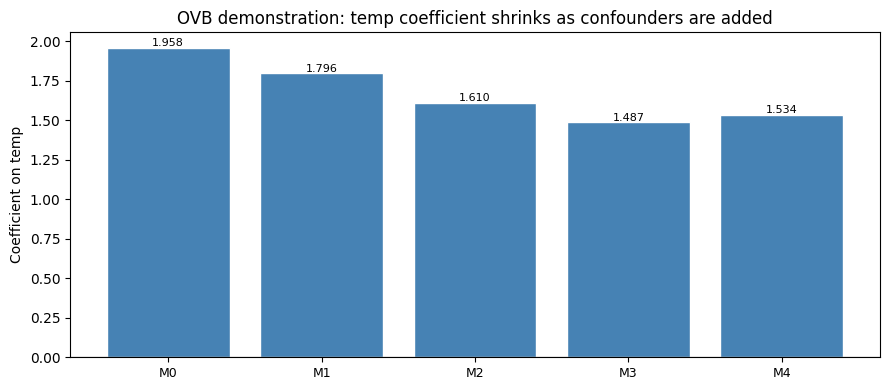

In [37]:
# Short vs long model: watch temp coefficient shrink as confounders are added
models = {
    'M0: temp only':                   'log_cnt ~ temp',
    'M1: + season':                    'log_cnt ~ temp + C(season)',
    'M2: + season + yr':               'log_cnt ~ temp + C(season) + yr',
    'M3: + season + yr + weathersit':  'log_cnt ~ temp + C(season) + yr + C(weathersit)',
    'M4: + all weather':               'log_cnt ~ temp + C(season) + yr + C(weathersit) + hum + windspeed',
}

results = []
for label, formula in models.items():
    fit = smf.ols(formula, data=train).fit()
    results.append({
        'Model': label,
        'temp coef': fit.params['temp'],
        'temp p-val': fit.pvalues['temp'],
        'R-squared': fit.rsquared,
    })

ovb_df = pd.DataFrame(results).set_index('Model')
print(ovb_df.round(4))

# Plot: temp coefficient across models
fig, ax = plt.subplots(figsize=(9, 4))
coefs = ovb_df['temp coef']
ax.bar(range(len(coefs)), coefs, color='steelblue', edgecolor='white')
ax.set_xticks(range(len(coefs)))
ax.set_xticklabels([m.split(':')[0] for m in coefs.index], fontsize=9)
ax.set_ylabel('Coefficient on temp')
ax.set_title('OVB demonstration: temp coefficient shrinks as confounders are added')
ax.axhline(0, color='black', linewidth=0.8)
for i, (v, pv) in enumerate(zip(coefs, ovb_df['temp p-val'])):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('fig_task2_ovb.png', dpi=150, bbox_inches='tight')
plt.show()

**Discussion: Omitted Variable Bias:**

**Correlation table:** A variable biases the simple temp coefficient upward when it correlates
positively with both **temp** and **cnt**, or negatively with both. The table shows:
- **season**, **mnth**, **atemp** => positive with both => **upward bias**
- **weathersit**, **windspeed**, **hum** => negative with temp, negative with cnt => **upward bias**
- **yr** => near-zero correlation with temp but strong positive correlation with cnt => **upward bias**
- **weekday**, **holiday**, **workingday** => near-zero with temp => negligible bias

**Short vs long model:** The temp coefficient drops progressively as confounders are added:
- M0 (temp only): coef ≈ 1.96 (the biased baseline)
- M1 (+ season): coef drops substantially (season was the dominant confounder)
- M2 (+ yr): coef drops further (year trend was also inflating the temp effect)
- M3 (+ weathersit): further reduction (bad weather days are cold AND low-demand)
- M4 (+ hum + windspeed): stabilises (remaining weather variables add little)

The total OVB = M0 coef − M4 coef, representing the portion of the original temperature
effect that was actually driven by season, year, and weather conditions rather than temperature itself.

**Conclusion:** The simple model overstates the marginal effect of temperature. Season is the
dominant confounder. A multiple regression controlling for these variables (Task 3) is needed
before any causal interpretation of the temperature coefficient.

## 2.6 Summary

| | Model 1: cnt ~ temp | Model 2: log(cnt) ~ temp |
|---|---|---|
| R-squared | **0.394** | 0.353 |
| Residual normality | **Good** (Skew=0.18, Kurt=2.50) | Poor (Skew=-2.61, Kurt=24.15) |
| Homoscedasticity | Mild concern | Worse (outlier dominates) |
| Linearity | Wave pattern in residuals vs fitted | Similar issue remains |
| Verdict | **Preferred** | Not justified here |

**Preferred simple model: `cnt ~ temp`.** The log transformation is not supported by the
diagnostic evidence in the bivariate setting as it reduces R-squared and dramatically worsens
normality, driven by the extreme outlier day (cnt = 22). Model 1 has approximately normal
residuals and only mild heteroscedasticity.

The main unresolved issue in both models is the non-linear (wave-shaped) pattern in the
residuals vs fitted plot, which the quadratic term in Section 2.4 partially addresses. The
decision on whether to use log(cnt) will be revisited in Task 3 after controlling for season,
year, and weather where the outlier's influence may be better managed. More transformation can be explored such as polynomial 